# foot_gait weight 0.1 vs 0.5 — 보행 비교

`foot_gait` reward는 **명령된 trot 위상**(`period=0.6s`, `offset=[0,0.5,0.5,0]`, duty `<0.56`)과
실제 발 접촉 상태가 일치할 때 보상을 준다 (`src/tasks/velocity/mdp/rewards.py:feet_gait`).
weight를 `0.10 → 0.50` 으로 키우면 정책이 trot 리듬을 더 강하게 따르도록 압박한다.

두 checkpoint를 **동일 명령(vx=0.5 m/s 직진)** 으로 rollout 하면서 비교한다:

| task | foot_gait weight | checkpoint |
|---|---|---|
| `Unitree-Go2-Flat-DeployDR-v0` | 0.10 | `..._deploy_gait01_h100_seed42` |
| `Unitree-Go2-Flat-DeployDR-Gait05-v0` | 0.50 | `..._deploy_gait05_h100_seed42` |

**수집 항목**: 발 높이(world z) 시계열 · 접촉 패턴(gait diagram) · swing 궤적(base 기준 x–z limb cycle) · 요약 지표.

발 순서: `FR, FL, RR, RL`. trot 대각쌍 = `(FR,RL)` / `(FL,RR)`.

In [1]:
# ── setup & config ───────────────────────────────────────────────────────
import gc, logging, os
logging.getLogger().setLevel(logging.WARNING)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
try:
    import warp as wp; wp.config.quiet = True   # mute warp kernel-load spam
except Exception:
    pass

from dataclasses import asdict
import numpy as np
import torch
import matplotlib.pyplot as plt

import mjlab            # noqa: F401
import mjlab.tasks      # noqa: F401
import src.tasks        # noqa: F401
from mjlab.envs import ManagerBasedRlEnv
from mjlab.managers.scene_entity_config import SceneEntityCfg
from mjlab.rl import RslRlVecEnvWrapper
from mjlab.tasks.registry import load_env_cfg, load_rl_cfg, load_runner_cls
from mjlab.utils.lab_api.math import quat_apply_inverse, yaw_quat
from src.utils.heading_lock import apply_heading_lock_velocity

DEVICE     = "cuda:0"
VX         = 0.5      # forward velocity command [m/s]
N_STEPS    = 400     # policy steps per rollout (step_dt=0.02s -> 8s, ~13 gait cycles)
WARMUP     = 50      # discard initial transient after reset
SEED       = 42
FOOT_NAMES = ["FR", "FL", "RR", "RL"]

RUNS = {
    0.1: ("Unitree-Go2-Flat-DeployDR-v0",
          "logs/rsl_rl/go2_velocity/2026-05-20_16-03-43_deploy_gait01_h100_seed42/model_4999.pt"),
    0.5: ("Unitree-Go2-Flat-DeployDR-Gait05-v0",
          "logs/rsl_rl/go2_velocity/2026-05-20_16-03-49_deploy_gait05_h100_seed42/model_4999.pt"),
}
COLORS = {0.1: "tab:blue", 0.5: "tab:red"}

In [2]:
# ── rollout + helpers ────────────────────────────────────────────────────
def rollout(task_id, ckpt, n_steps=N_STEPS, vx=VX, seed=SEED, device=DEVICE):
    """Load env+policy for `task_id`, drive vx command, collect per-step foot data."""
    torch.manual_seed(seed)
    env_cfg = load_env_cfg(task_id, play=True)
    agent_cfg = load_rl_cfg(task_id)
    env_cfg.scene.num_envs = 1
    env = ManagerBasedRlEnv(cfg=env_cfg, device=device, render_mode=None)
    apply_heading_lock_velocity(env, vx=vx, vy=0.0, wz=0.0, device=device)

    robot = env.scene["robot"]
    foot_cfg = SceneEntityCfg("robot", site_names=tuple(FOOT_NAMES)); foot_cfg.resolve(env.scene)
    site_ids = foot_cfg.site_ids
    g = env.reward_manager.get_term_cfg("foot_gait").params
    period, offset, thr = g["period"], np.array(g["offset"]), g["threshold"]
    step_dt = env.step_dt
    contact = env.scene["feet_ground_contact"]

    venv = RslRlVecEnvWrapper(env, clip_actions=agent_cfg.clip_actions)
    runner = (load_runner_cls(task_id))(venv, asdict(agent_cfg), device=device)
    runner.load(ckpt, load_cfg={"actor": True}, strict=True, map_location=device)
    policy = runner.get_inference_policy(device=device)

    rec = {k: [] for k in ["foot_z", "foot_base_x", "contact", "stance_cmd", "base_h", "vx"]}
    obs, _ = venv.reset()
    for _ in range(n_steps):
        with torch.inference_mode():
            actions = policy(obs)
        obs, _, _, _ = venv.step(actions)
        foot_w = robot.data.site_pos_w[0, site_ids]            # [4,3] world
        root_p = robot.data.root_link_pos_w[0]                 # [3]
        root_q = robot.data.root_link_quat_w[0]                # [4] wxyz
        qy = yaw_quat(root_q.unsqueeze(0)).expand(4, -1)       # yaw-only -> base frame
        foot_b = quat_apply_inverse(qy, foot_w - root_p)       # [4,3] foot rel. base (x fwd)
        rec["foot_z"].append(foot_w[:, 2].cpu().numpy())
        rec["foot_base_x"].append(foot_b[:, 0].cpu().numpy())
        rec["contact"].append((contact.data.current_contact_time[0] > 0).cpu().numpy().reshape(-1))
        ep = env.episode_length_buf[0].item()                  # commanded gait clock
        rec["stance_cmd"].append(((ep * step_dt) / period + offset) % 1.0 < thr)
        rec["base_h"].append(root_p[2].item())
        rec["vx"].append(robot.data.root_link_lin_vel_b[0, 0].item())
    venv.close()
    del venv, env, runner, policy; gc.collect(); torch.cuda.empty_cache()
    out = {k: np.array(v) for k, v in rec.items()}
    out["t"] = np.arange(n_steps) * step_dt
    out["step_dt"] = step_dt
    return out


def bool_segments(mask, t, dt):
    """Contiguous True runs -> list of (start_time, width) for bar plotting."""
    segs, i, n = [], 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            segs.append((t[i], (j - i) * dt)); i = j
        else:
            i += 1
    return segs


def swing_peaks(z_col, contact_col):
    """Max foot height within each airborne (swing) interval."""
    air, peaks, i, n = ~contact_col, [], 0, len(contact_col)
    while i < n:
        if air[i]:
            j = i
            while j < n and air[j]:
                j += 1
            peaks.append(z_col[i:j].max()); i = j
        else:
            i += 1
    return np.array(peaks)

In [3]:
# ── run both rollouts (sequential; env rebuilt per weight) ────────────────
data = {}
for w, (task, ckpt) in RUNS.items():
    print(f"rolling out  weight={w}  ({task})")
    data[w] = rollout(task, ckpt)
sl = slice(WARMUP, None)
print("done. step_dt =", data[0.1]["step_dt"], "s")

rolling out  weight=0.1  (Unitree-Go2-Flat-DeployDR-v0)
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 5080" (15 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/rbdo/.cache/warp/1.12.0
Warp DeprecationWarning: The symbol `warp.context.runtime` will soon be removed from the public API. It can still be accessed from `warp._src.context.runtime` but might be changed or removed without notice.
Module mujoco_warp._src.smooth f756680 load on device 'cuda:0' took 6.44 ms  (cached)
Module mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.62 ms  (cached)
Module _nxn_broadphase__locals__kernel_e916423b e916423 load on device 'cuda:0' took 0.65 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_7f28fe80 7f28fe8 load on device 'cuda:0' took 0.90 ms  (cached)
Module mujoco_warp._src.constraint 63c97cb load on device 'cuda:0' took 3.65 ms  (cached)
Module mu

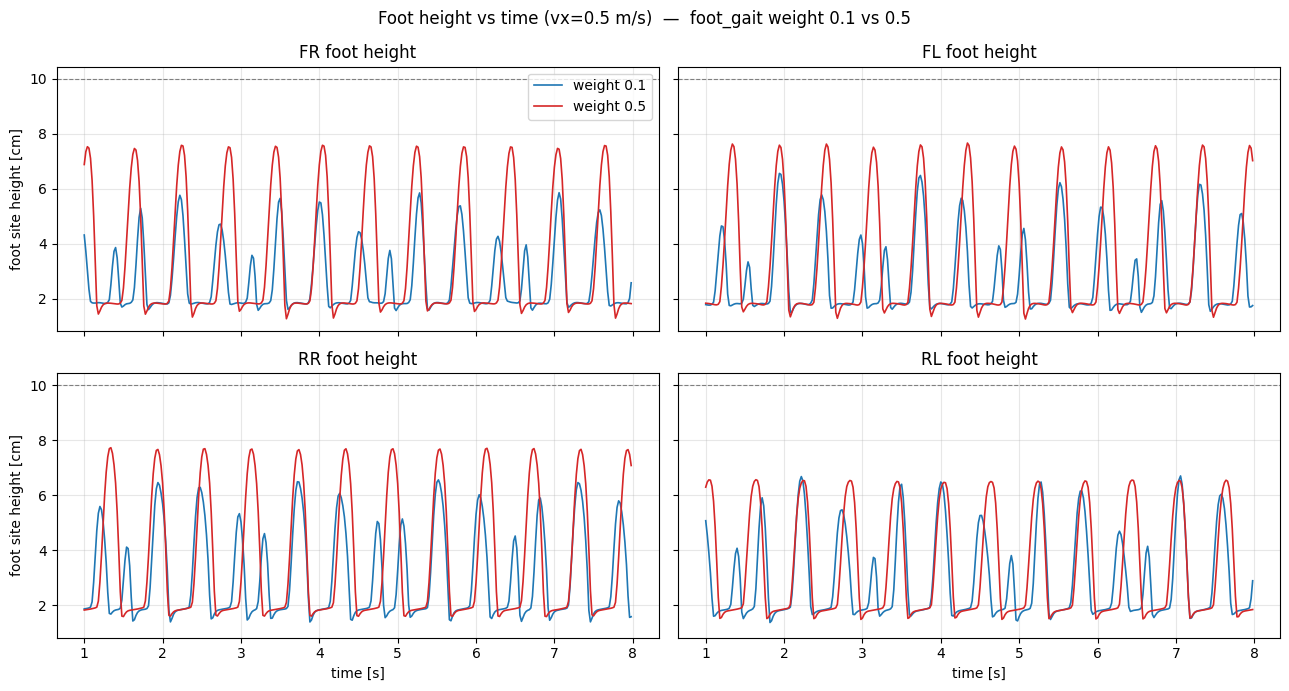

In [4]:
# ── 1. foot height vs time ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for k, ax in enumerate(axes.flat):
    for w in RUNS:
        d = data[w]
        ax.plot(d["t"][sl], d["foot_z"][sl, k] * 100, color=COLORS[w], lw=1.2, label=f"weight {w}")
    ax.axhline(10.0, ls="--", c="gray", lw=0.8)   # feet_clearance target_height = 0.10 m
    ax.set_title(f"{FOOT_NAMES[k]} foot height")
    ax.grid(alpha=0.3)
    if k % 2 == 0:
        ax.set_ylabel("foot site height [cm]")
    if k // 2 == 1:
        ax.set_xlabel("time [s]")
axes.flat[0].legend(loc="upper right")
fig.suptitle(f"Foot height vs time (vx={VX} m/s)  —  foot_gait weight 0.1 vs 0.5")
fig.tight_layout(); plt.show()

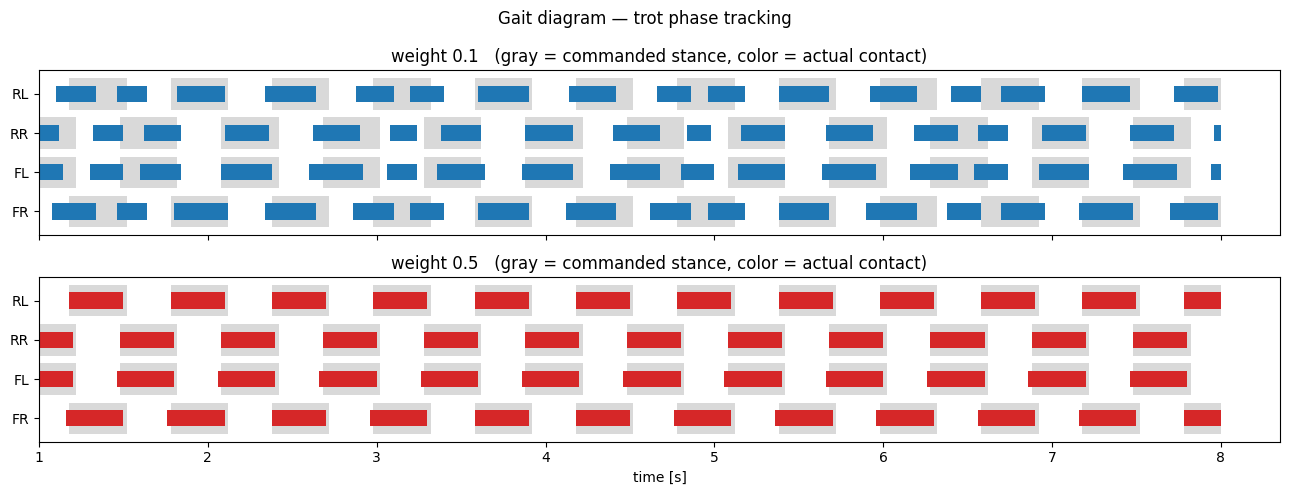

In [5]:
# ── 2. gait diagram: gray = commanded stance, color = actual contact ──────
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 5), sharex=True)
for ax, w in zip(np.atleast_1d(axes), RUNS):
    d = data[w]; t = d["t"][sl]; dt = d["step_dt"]
    for k in range(4):
        for x0, wd in bool_segments(d["stance_cmd"][sl, k], t, dt):
            ax.barh(k, wd, left=x0, height=0.8, color="0.85")            # commanded stance
        for x0, wd in bool_segments(d["contact"][sl, k], t, dt):
            ax.barh(k, wd, left=x0, height=0.42, color=COLORS[w])        # actual contact
    ax.set_yticks(range(4)); ax.set_yticklabels(FOOT_NAMES); ax.set_ylim(-0.6, 3.6)
    ax.set_title(f"weight {w}   (gray = commanded stance, color = actual contact)")
ax.set_xlabel("time [s]")
fig.suptitle("Gait diagram — trot phase tracking")
fig.tight_layout(); plt.show()

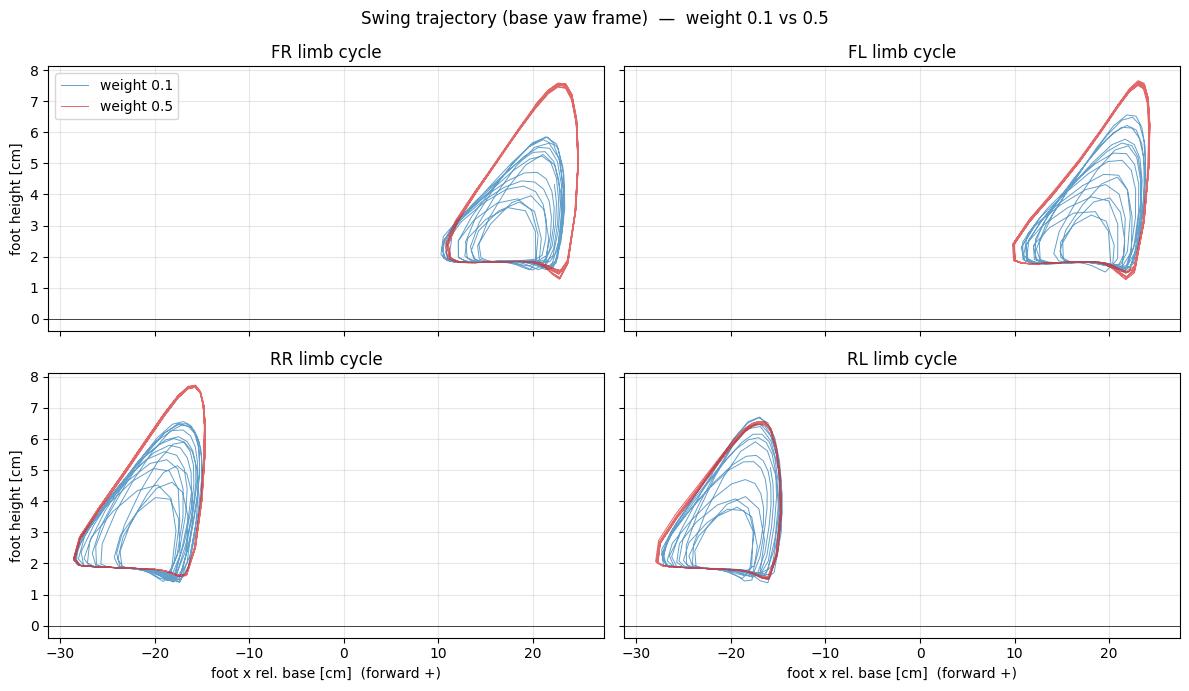

In [6]:
# ── 3. swing trajectory / limb cycle (base frame x vs height) ─────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for k, ax in enumerate(axes.flat):
    for w in RUNS:
        d = data[w]
        ax.plot(d["foot_base_x"][sl, k] * 100, d["foot_z"][sl, k] * 100,
                color=COLORS[w], lw=0.7, alpha=0.7, label=f"weight {w}")
    ax.set_title(f"{FOOT_NAMES[k]} limb cycle")
    ax.axhline(0, c="k", lw=0.5); ax.grid(alpha=0.3)
    if k % 2 == 0:
        ax.set_ylabel("foot height [cm]")
    if k // 2 == 1:
        ax.set_xlabel("foot x rel. base [cm]  (forward +)")
axes.flat[0].legend()
fig.suptitle("Swing trajectory (base yaw frame)  —  weight 0.1 vs 0.5")
fig.tight_layout(); plt.show()

 weight    duty  gaitMatch  swingPeak[cm]  vx[m/s]  baseH[cm]
    0.1   0.576      0.707           5.17    0.421      30.33
    0.5   0.546      0.954           7.33    0.419      30.40


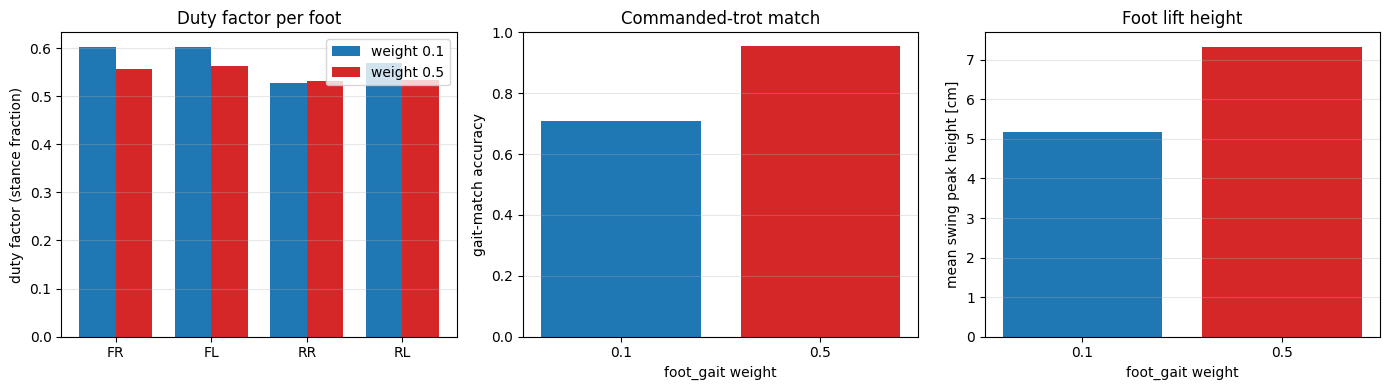

In [7]:
# ── 4. summary metrics ────────────────────────────────────────────────────
rows = {}
for w in RUNS:
    d = data[w]
    c, cmd, z = d["contact"][sl], d["stance_cmd"][sl], d["foot_z"][sl]
    duty_per_foot = c.mean(axis=0)
    match = (c == cmd).mean()                                  # == feet_gait reward core
    peaks = np.concatenate([swing_peaks(z[:, k], c[:, k]) for k in range(4)])
    rows[w] = dict(duty=duty_per_foot, match=match,
                   swing=np.nanmean(peaks) * 100, vx=d["vx"][sl].mean(),
                   base_h=d["base_h"][sl].mean() * 100)

print(f"{'weight':>7} {'duty':>7} {'gaitMatch':>10} {'swingPeak[cm]':>14} {'vx[m/s]':>8} {'baseH[cm]':>10}")
for w in RUNS:
    r = rows[w]
    print(f"{w:>7} {r['duty'].mean():>7.3f} {r['match']:>10.3f} {r['swing']:>14.2f} {r['vx']:>8.3f} {r['base_h']:>10.2f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(4); bw = 0.38
for i, w in enumerate(RUNS):
    ax[0].bar(x + (i - 0.5) * bw, rows[w]["duty"], bw, color=COLORS[w], label=f"weight {w}")
ax[0].set_xticks(x); ax[0].set_xticklabels(FOOT_NAMES); ax[0].set_ylabel("duty factor (stance fraction)")
ax[0].set_title("Duty factor per foot"); ax[0].legend(); ax[0].grid(alpha=0.3, axis="y")

ws = list(RUNS)
ax[1].bar([str(w) for w in ws], [rows[w]["match"] for w in ws], color=[COLORS[w] for w in ws])
ax[1].set_ylim(0, 1); ax[1].set_ylabel("gait-match accuracy"); ax[1].set_xlabel("foot_gait weight")
ax[1].set_title("Commanded-trot match"); ax[1].grid(alpha=0.3, axis="y")

ax[2].bar([str(w) for w in ws], [rows[w]["swing"] for w in ws], color=[COLORS[w] for w in ws])
ax[2].set_ylabel("mean swing peak height [cm]"); ax[2].set_xlabel("foot_gait weight")
ax[2].set_title("Foot lift height"); ax[2].grid(alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

## 해석 포인트

- **gait-match accuracy**: `feet_gait` reward의 핵심 양 `(is_stance == is_contact).mean()`. weight를 키우면 명령된 trot 위상에 더 충실해진다 → 값이 1.0에 가까워질수록 깨끗한 trot.
- **gait diagram**: 회색(명령 stance) 박스 안에 색(실제 접촉) 박스가 잘 채워질수록 위상 추종이 좋다. 색이 회색을 벗어나거나 회색이 빈 칸이면 mismatch.
- **swing peak height / limb cycle**: weight가 클수록 swing 구간에서 발을 더 또렷이 들어올리고(arc 면적↑), 접촉/비접촉 구분이 선명해지는 경향.
- **duty factor**: 0.5 근처면 균형 잡힌 trot. 너무 높으면 발을 끌고(거의 항상 접촉), 너무 낮으면 체공이 길다.

> 발 높이는 site의 world z(평지 가정, 지면 z≈0 기준)이다. `foot x rel. base`는 base를 yaw 정렬한 프레임에서의 전후 위치로, swing이 앞으로 뻗고 stance가 뒤로 쓸려가는 limb cycle을 보여준다.